## Install and imports

In [4]:
import site
site.addsitedir(site.getusersitepackages())

In [5]:
import numpy as np
import pandas as pd

from sklearn.model_selection import RepeatedStratifiedKFold, GroupKFold
from sklearn.metrics import (
    roc_auc_score, f1_score, confusion_matrix,
    precision_recall_curve, auc, roc_curve
)

from catboost import CatBoostClassifier, Pool
import matplotlib.pyplot as plt 
%matplotlib inline

In [6]:
import os, platform, shutil, time
import numpy as np
import pandas as pd
import sklearn

def bytes_to_gb(x):
    return x / (1024**3)

# OS and Python
sys_info = {
    "OS": platform.platform(),
    "Machine": platform.machine(),
    "Processor": platform.processor(),
    "Python": platform.python_version(),
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "scikit-learn": sklearn.__version__,
}

print("=== SOFTWARE ===")
for k, v in sys_info.items():
    print(f"{k}: {v}")

# CPU cores
print("\n=== CPU ===")
print("Logical cores:", os.cpu_count())

# RAM (Linux-friendly). If this fails on your system, it will skip.
print("\n=== RAM ===")
try:
    import psutil
    vm = psutil.virtual_memory()
    print(f"Total RAM: {bytes_to_gb(vm.total):.2f} GB")
except Exception:
    # Fallback for Linux without psutil
    try:
        import subprocess
        out = subprocess.check_output(["bash", "-lc", "free -g"]).decode()
        print(out)
    except Exception as e:
        print("RAM check unavailable:", e)

# Disk
print("\n=== DISK ===")
usage = shutil.disk_usage(".")
print(f"Disk total: {bytes_to_gb(usage.total):.2f} GB")
print(f"Disk free:  {bytes_to_gb(usage.free):.2f} GB")

# GPU (optional)
print("\n=== GPU ===")
try:
    import subprocess
    out = subprocess.check_output(["bash", "-lc", "nvidia-smi --query-gpu=name,memory.total --format=csv,noheader"]).decode().strip()
    print(out if out else "No GPU detected")
except Exception:
    print("No GPU detected (or nvidia-smi not available)")

=== SOFTWARE ===
OS: Linux-5.14.0-570.42.2.el9_6.x86_64-x86_64-with-glibc2.34
Machine: x86_64
Processor: x86_64
Python: 3.10.4
pandas: 1.4.2
numpy: 1.22.3
scikit-learn: 1.7.2

=== CPU ===
Logical cores: 128

=== RAM ===
Total RAM: 376.83 GB

=== DISK ===
Disk total: 4113624.83 GB
Disk free:  1394601.72 GB

=== GPU ===


flatpak: /opt/software/software/util-linux/2.38-GCCcore-11.3.0/lib/libmount.so.1: version `MOUNT_2_40' not found (required by /lib64/libgio-2.0.so.0)


No GPU detected (or nvidia-smi not available)


## Load data

In [19]:
df = pd.read_csv("ListeriaSoil_clean.csv")
meta = pd.read_csv("ListeriaSoil_Metadata.csv")

print("df shape:", df.shape)
display(df.head())
display(meta.tail(10))

df shape: (622, 35)


,Latitude,Longitude,Elevation (m),Moisture,Total nitrogen (%),Total carbon (%),pH,Organic matter (%),Aluminum (mg/Kg),Calcium (mg/Kg),...,Developed open space (< 20% Impervious Cover) (%),Developed open space (> 20% Impervious Cover) (%),Barren (%),Forest (%),Shrubland (%),Grassland (%),Cropland (%),Pasture (%),Wetland (%),Number of Listeria isolates obtained
0,35.4740,-83.8701,487.79,0.4280,0.2138,4.7973,4.639,7.3493,140.7795,73.6060,...,1.6472,0.1679,0.0275,94.9182,0.2783,0.1173,0.1530,0.0,0.0577,6.0
1,35.4850,-83.8675,584.73,0.4241,0.2226,5.0271,4.677,7.0913,116.8586,142.0197,...,1.4449,0.1331,0.0279,95.2959,0.3105,0.1056,0.1136,0.0,0.0577,4.0
2,35.4815,-83.8587,779.80,0.4425,0.2198,7.4885,4.102,11.5970,126.6213,153.0297,...,1.4779,0.1346,0.0317,95.1514,0.2998,0.1073,0.1415,0.0,0.0577,6.0
3,35.4844,-83.8381,707.26,1.0843,0.4780,7.5004,5.396,11.0852,137.5845,1098.0060,...,1.2952,0.1345,0.0548,95.0007,0.3064,0.0917,0.1326,0.0,0.0577,8.0
4,35.4727,-83.8513,587.15,0.4674,0.3683,8.8855,4.486,10.8152,139.4947,162.7989,...,1.6141,0.1736,0.0462,94.5999,0.2758,0.1194,0.1729,0.0,0.0577,6.0


,Variable,Description,Type
25,Developed open space (< 20% Impervious Cover) (%),Percentage of developed open space (< 20% Impe...,Predictor
26,Developed open space (> 20% Impervious Cover) (%),Percentage of developed open space (>20% Imper...,Predictor
27,Barren (%),Percentage of barren land,Predictor
28,Forest (%),Percentage of forest,Predictor
29,Shrubland (%),Percentage of shrubland,Predictor
30,Grassland (%),Percentage of grassland,Predictor
31,Cropland (%),Percentage of cropland,Predictor
32,Pasture (%),Percentage of pasture,Predictor
33,Wetland (%),Percentage of wetland,Predictor
34,Listeria,The Listeria is present if the number of Liste...,Outcome


## Create the target (binary) and define features

In [20]:
TARGET_COUNT = "Number of Listeria isolates obtained"

df["y"] = (df[TARGET_COUNT] > 0).astype(int)

print("Class balance:")
print(df["y"].value_counts(), "\nPositive rate:", df["y"].mean())

X = df.drop(columns=[TARGET_COUNT, "y"])
y = df["y"].values

print("X shape:", X.shape)

Class balance:
1    311
0    311
Name: y, dtype: int64 
Positive rate: 0.5
X shape: (622, 34)


## Quick sanity checks

In [30]:
print("Any missing values?", X.isna().any().any())
print("Dtypes summary:")
print(X.dtypes.value_counts())

# Check that Latitude/Longitude exist
assert "Latitude" in X.columns and "Longitude" in X.columns

Any missing values? False
Dtypes summary:
float64    34
dtype: int64


## Metrics + threshold tuning helpers

In [31]:
def pr_auc_score(y_true, y_prob):
    p, r, _ = precision_recall_curve(y_true, y_prob)
    return auc(r, p)

def sensitivity_specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sens = tp / (tp + fn) if (tp + fn) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    return sens, spec

def tune_threshold_for_f1(y_true, y_prob, t_min=0.05, t_max=0.95, steps=181):
    ts = np.linspace(t_min, t_max, steps)
    best_t, best_f1 = 0.5, -1.0
    for t in ts:
        f1 = f1_score(y_true, (y_prob >= t).astype(int))
        if f1 > best_f1:
            best_f1 = f1
            best_t = float(t)
    return best_t, float(best_f1)

def summarize_probs(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    out = {
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": pr_auc_score(y_true, y_prob),
        "f1": f1_score(y_true, y_pred),
    }
    sens, spec = sensitivity_specificity(y_true, y_pred)
    out["sensitivity"] = sens
    out["specificity"] = spec
    out["threshold"] = threshold
    return out

## Define CV splits (random CV and spatial CV)

In [32]:
N_SPLITS = 5
N_REPEATS = 3
SEED = 42

rskf = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=SEED)
random_splits = list(rskf.split(np.zeros(len(y)), y))

def make_spatial_groups(df_features, grid_size_deg=0.5):
    lat_bin = np.floor(df_features["Latitude"].astype(float) / grid_size_deg).astype(int)
    lon_bin = np.floor(df_features["Longitude"].astype(float) / grid_size_deg).astype(int)
    return (lat_bin.astype(str) + "_" + lon_bin.astype(str)).values

GRID_SIZE_DEG = 0.5
groups = make_spatial_groups(X, grid_size_deg=GRID_SIZE_DEG)

gkf = GroupKFold(n_splits=N_SPLITS)
spatial_splits = list(gkf.split(np.zeros(len(y)), y, groups))

print("Random splits:", len(random_splits), "Spatial splits:", len(spatial_splits))

Random splits: 15 Spatial splits: 5


## Train with CatBoost using OOF predictions

In [33]:
CAT_PARAMS = dict(
    loss_function="Logloss",
    eval_metric="AUC",
    iterations=20000,
    learning_rate=0.03,
    depth=8,
    l2_leaf_reg=3.0,
    random_seed=SEED,
    allow_writing_files=False,
    verbose=200,
    od_type="Iter",
    od_wait=300,
)

def run_catboost_cv(X, y, splits, label):
    # Identify categorical columns if any (your dataset is usually all numeric)
    cat_cols = [c for c in X.columns if X[c].dtype == "object"]
    cat_idx = [X.columns.get_loc(c) for c in cat_cols]

    oof = np.zeros(len(y), dtype=float)
    rows = []

    for fold, (tr, va) in enumerate(splits, start=1):
        X_tr, y_tr = X.iloc[tr], y[tr]
        X_va, y_va = X.iloc[va], y[va]

        train_pool = Pool(X_tr, y_tr, cat_features=cat_idx)
        valid_pool = Pool(X_va, y_va, cat_features=cat_idx)

        model = CatBoostClassifier(**CAT_PARAMS)
        model.fit(train_pool, eval_set=valid_pool, use_best_model=True)

        va_prob = model.predict_proba(valid_pool)[:, 1]
        oof[va] = va_prob

        fold_metrics = summarize_probs(y_va, va_prob, threshold=0.5)
        fold_metrics["fold"] = fold
        fold_metrics["cv_type"] = label
        rows.append(fold_metrics)

        print(f"[{label} fold {fold}] AUC={fold_metrics['roc_auc']:.4f} F1@0.5={fold_metrics['f1']:.4f}")

    best_t, best_f1 = tune_threshold_for_f1(y, oof)
    overall = summarize_probs(y, oof, threshold=best_t)
    overall["best_f1_objective"] = best_f1
    overall["cv_type"] = label

    return oof, pd.DataFrame(rows), overall

oof_random, folds_random, overall_random = run_catboost_cv(X, y, random_splits, "random_repeated_stratified")
oof_spatial, folds_spatial, overall_spatial = run_catboost_cv(X, y, spatial_splits, "spatial_groupkfold")

display(folds_random.head())
display(folds_spatial.head())
print("OVERALL RANDOM:", overall_random)
print("OVERALL SPATIAL:", overall_spatial)

0:	test: 0.7850742	best: 0.7850742 (0)	total: 52.6ms	remaining: 17m 31s
200:	test: 0.9434204	best: 0.9439324 (125)	total: 1.08s	remaining: 1m 46s
400:	test: 0.9470046	best: 0.9482847 (284)	total: 2.14s	remaining: 1m 44s
600:	test: 0.9470046	best: 0.9485407 (430)	total: 3.25s	remaining: 1m 44s
Stopped by overfitting detector  (300 iterations wait)

bestTest = 0.9485407066
bestIteration = 430

Shrink model to first 431 iterations.
[random_repeated_stratified fold 1] AUC=0.9485 F1@0.5=0.8710
0:	test: 0.8074757	best: 0.8074757 (0)	total: 7.25ms	remaining: 2m 25s
200:	test: 0.9534050	best: 0.9534050 (200)	total: 1.09s	remaining: 1m 46s
400:	test: 0.9564772	best: 0.9575013 (344)	total: 2.18s	remaining: 1m 46s
600:	test: 0.9564772	best: 0.9575013 (344)	total: 3.25s	remaining: 1m 44s
Stopped by overfitting detector  (300 iterations wait)

bestTest = 0.9575012801
bestIteration = 344

Shrink model to first 345 iterations.
[random_repeated_stratified fold 2] AUC=0.9575 F1@0.5=0.9008
0:	test: 0.78

,roc_auc,pr_auc,f1,sensitivity,specificity,threshold,fold,cv_type
0,0.948541,0.948665,0.870968,0.857143,0.887097,0.5,1,random_repeated_stratified
1,0.957501,0.958204,0.900763,0.951613,0.841270,0.5,2,random_repeated_stratified
2,0.978668,0.979675,0.888889,0.967742,0.790323,0.5,3,random_repeated_stratified
3,0.949272,0.951506,0.873016,0.887097,0.854839,0.5,4,random_repeated_stratified
4,0.925338,0.908541,0.863636,0.919355,0.790323,0.5,5,random_repeated_stratified


,roc_auc,pr_auc,f1,sensitivity,specificity,threshold,fold,cv_type
0,0.873952,0.847452,0.756303,0.849057,0.708333,0.5,1,spatial_groupkfold
1,0.951357,0.950875,0.876923,0.919355,0.825397,0.5,2,spatial_groupkfold
2,0.915152,0.925991,0.877698,0.884058,0.836364,0.5,3,spatial_groupkfold
3,0.971838,0.976339,0.912000,0.876923,0.949153,0.5,4,spatial_groupkfold
4,0.960198,0.949380,0.929134,0.951613,0.903226,0.5,5,spatial_groupkfold


OVERALL RANDOM: {'roc_auc': 0.9458855884451154, 'pr_auc': 0.9397548354943231, 'f1': 0.9010989010989011, 'sensitivity': 0.9228295819935691, 'specificity': 0.8745980707395499, 'threshold': 0.43499999999999994, 'best_f1_objective': 0.9010989010989011, 'cv_type': 'random_repeated_stratified'}
OVERALL SPATIAL: {'roc_auc': 0.9335718199770474, 'pr_auc': 0.930099382822831, 'f1': 0.8801261829652997, 'sensitivity': 0.8971061093247589, 'specificity': 0.8585209003215434, 'threshold': 0.5049999999999999, 'best_f1_objective': 0.8801261829652997, 'cv_type': 'spatial_groupkfold'}


## Plot ROC, PR, and confusion matrix for the best CV

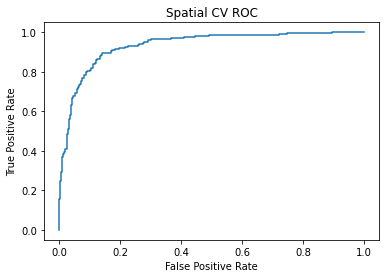

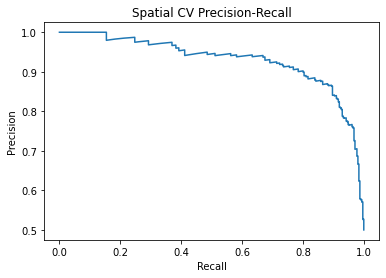

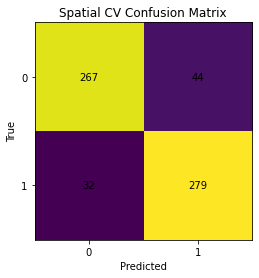

In [39]:
def plot_curves(y_true, y_prob, title_prefix=""):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    p, r, _ = precision_recall_curve(y_true, y_prob)

    plt.figure()
    plt.plot(fpr, tpr)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{title_prefix} ROC")
    plt.show()

    plt.figure()
    plt.plot(r, p)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{title_prefix} Precision-Recall")
    plt.show()

def plot_confusion(y_true, y_prob, threshold, title=""):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    plt.figure()
    plt.imshow(cm)
    plt.title(title)
    plt.xticks([0,1], ["0","1"])
    plt.yticks([0,1], ["0","1"])
    for (i,j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha="center", va="center")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

# Use spatial CV for report credibility
plot_curves(y, oof_spatial, title_prefix="Spatial CV")
plot_confusion(y, oof_spatial, overall_spatial["threshold"], title="Spatial CV Confusion Matrix")

## Train final model on all data + feature importance

In [40]:
cat_cols = [c for c in X.columns if X[c].dtype == "object"]
cat_idx = [X.columns.get_loc(c) for c in cat_cols]

full_pool = Pool(X, y, cat_features=cat_idx)
final_model = CatBoostClassifier(**CAT_PARAMS)
final_model.fit(full_pool)

importances = final_model.get_feature_importance(full_pool)
imp_df = pd.DataFrame({"feature": X.columns, "importance": importances}).sort_values("importance", ascending=False)

display(imp_df.head(15))

0:	total: 5.85ms	remaining: 1m 56s
200:	total: 939ms	remaining: 1m 32s
400:	total: 1.88s	remaining: 1m 31s
600:	total: 2.78s	remaining: 1m 29s
800:	total: 3.68s	remaining: 1m 28s
1000:	total: 4.59s	remaining: 1m 27s
1200:	total: 5.49s	remaining: 1m 25s
1400:	total: 6.47s	remaining: 1m 25s
1600:	total: 7.34s	remaining: 1m 24s
1800:	total: 8.24s	remaining: 1m 23s
2000:	total: 9.12s	remaining: 1m 22s
2200:	total: 9.91s	remaining: 1m 20s
2400:	total: 10.6s	remaining: 1m 17s
2600:	total: 11.4s	remaining: 1m 16s
2800:	total: 12.3s	remaining: 1m 15s
3000:	total: 13.2s	remaining: 1m 14s
3200:	total: 14.1s	remaining: 1m 14s
3400:	total: 15.1s	remaining: 1m 13s
3600:	total: 16s	remaining: 1m 12s
3800:	total: 17s	remaining: 1m 12s
4000:	total: 17.8s	remaining: 1m 11s
4200:	total: 18.6s	remaining: 1m 10s
4400:	total: 19.5s	remaining: 1m 9s
4600:	total: 20.5s	remaining: 1m 8s
4800:	total: 21.4s	remaining: 1m 7s
5000:	total: 22.3s	remaining: 1m 6s
5200:	total: 23.2s	remaining: 1m 5s
5400:	total: 24.

,feature,importance
16,Sodium (mg/Kg),18.320194
15,Molybdenum (mg/Kg),8.662675
3,Moisture,7.348143
10,Copper (mg/Kg),5.819529
12,Potassium (mg/Kg),4.206132
1,Longitude,4.161513
17,Phosphorus (mg/Kg),3.618273
19,Zinc (mg/Kg),3.594348
13,Magnesium (mg/Kg),3.498814
14,Manganese (mg/Kg),3.015507


## Save everything

In [41]:
import os, json

OUT_DIR = "outputs_notebook"
os.makedirs(OUT_DIR, exist_ok=True)

folds_all = pd.concat([folds_random, folds_spatial], ignore_index=True)
folds_all.to_csv(f"{OUT_DIR}/cv_fold_metrics.csv", index=False)

with open(f"{OUT_DIR}/cv_overall_metrics.json", "w") as f:
    json.dump({"random": overall_random, "spatial": overall_spatial}, f, indent=2)

pd.DataFrame({
    "y": y,
    "oof_prob_random": oof_random,
    "oof_prob_spatial": oof_spatial
}).to_csv(f"{OUT_DIR}/oof_predictions.csv", index=False)

imp_df.to_csv(f"{OUT_DIR}/feature_importance.csv", index=False)

final_model.save_model(f"{OUT_DIR}/catboost_final.cbm")

print("Saved outputs to:", OUT_DIR)

Saved outputs to: outputs_notebook


## LightGBM CV + OOF

In [43]:
import lightgbm as lgb

LGB_PARAMS = dict(
    objective="binary",
    learning_rate=0.03,
    n_estimators=5000,
    num_leaves=63,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=SEED,
)

def run_lgbm_cv(X, y, splits, label):
    oof = np.zeros(len(y), dtype=float)
    rows = []

    for fold, (tr, va) in enumerate(splits, start=1):
        X_tr, y_tr = X.iloc[tr], y[tr]
        X_va, y_va = X.iloc[va], y[va]

        model = lgb.LGBMClassifier(**LGB_PARAMS)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric="auc",
            callbacks=[lgb.early_stopping(stopping_rounds=200, verbose=False)]
        )

        va_prob = model.predict_proba(X_va)[:, 1]
        oof[va] = va_prob

        fold_metrics = summarize_probs(y_va, va_prob, threshold=0.5)
        fold_metrics["fold"] = fold
        fold_metrics["cv_type"] = label
        rows.append(fold_metrics)

        print(f"[{label} fold {fold}] AUC={fold_metrics['roc_auc']:.4f} F1@0.5={fold_metrics['f1']:.4f}")

    best_t, best_f1 = tune_threshold_for_f1(y, oof)
    overall = summarize_probs(y, oof, threshold=best_t)
    overall["best_f1_objective"] = best_f1
    overall["cv_type"] = label
    return oof, pd.DataFrame(rows), overall

oof_lgb_spatial, folds_lgb_spatial, overall_lgb_spatial = run_lgbm_cv(X, y, spatial_splits, "lgbm_spatial")
print("OVERALL LGB SPATIAL:", overall_lgb_spatial)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 258, number of negative: 239
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000970 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5352
[LightGBM] [Info] Number of data points in the train set: 497, number of used features: 34
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.519115 -> initscore=0.076496
[LightGBM] [Info] Start training from score 0.076496
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

## Average CatBoost and LightGBM probabilities, then retune threshold.

OVERALL ENSEMBLE SPATIAL: {'roc_auc': 0.9358050475077802, 'pr_auc': 0.9340882044170444, 'f1': 0.8708609271523179, 'sensitivity': 0.8456591639871383, 'specificity': 0.9035369774919614, 'threshold': 0.61, 'best_f1_objective': 0.8708609271523179, 'cv_type': 'ensemble_spatial'}


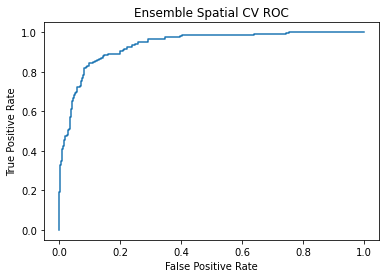

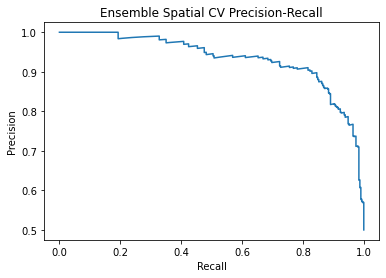

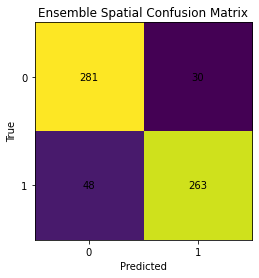

In [44]:
oof_ens_spatial = 0.5 * oof_spatial + 0.5 * oof_lgb_spatial
best_t_ens, best_f1_ens = tune_threshold_for_f1(y, oof_ens_spatial)
overall_ens_spatial = summarize_probs(y, oof_ens_spatial, threshold=best_t_ens)
overall_ens_spatial["best_f1_objective"] = best_f1_ens
overall_ens_spatial["cv_type"] = "ensemble_spatial"

print("OVERALL ENSEMBLE SPATIAL:", overall_ens_spatial)

plot_curves(y, oof_ens_spatial, title_prefix="Ensemble Spatial CV")
plot_confusion(y, oof_ens_spatial, overall_ens_spatial["threshold"], title="Ensemble Spatial Confusion Matrix")

## Grid-size sensitivity

In [45]:
def spatial_splits_for_grid(X, y, grid):
    groups = make_spatial_groups(X, grid_size_deg=grid)
    gkf = GroupKFold(n_splits=N_SPLITS)
    return list(gkf.split(np.zeros(len(y)), y, groups))

for grid in [0.25, 0.5, 1.0]:
    splits = spatial_splits_for_grid(X, y, grid)
    oof_cb, _, overall_cb = run_catboost_cv(X, y, splits, f"cb_spatial_grid_{grid}")
    print("Grid", grid, "Overall:", overall_cb)

0:	test: 0.7321429	best: 0.7321429 (0)	total: 11.1ms	remaining: 3m 41s
200:	test: 0.9019151	best: 0.9029503 (196)	total: 1.07s	remaining: 1m 45s
400:	test: 0.9086439	best: 0.9104555 (278)	total: 1.92s	remaining: 1m 33s
Stopped by overfitting detector  (300 iterations wait)

bestTest = 0.9104554865
bestIteration = 278

Shrink model to first 279 iterations.
[cb_spatial_grid_0.25 fold 1] AUC=0.9105 F1@0.5=0.8714
0:	test: 0.7844427	best: 0.7844427 (0)	total: 5.01ms	remaining: 1m 40s
200:	test: 0.9334365	best: 0.9352425 (185)	total: 850ms	remaining: 1m 23s
400:	test: 0.9360165	best: 0.9391125 (252)	total: 1.91s	remaining: 1m 33s
600:	test: 0.9396285	best: 0.9398865 (549)	total: 2.75s	remaining: 1m 28s
800:	test: 0.9409185	best: 0.9414345 (790)	total: 3.57s	remaining: 1m 25s
1000:	test: 0.9401445	best: 0.9416925 (874)	total: 4.4s	remaining: 1m 23s
Stopped by overfitting detector  (300 iterations wait)

bestTest = 0.9416924665
bestIteration = 874

Shrink model to first 875 iterations.
[cb_spa

## Inspect spatial group sizes

In [46]:
grid = 0.25
groups025 = make_spatial_groups(X, grid_size_deg=grid)
g = pd.Series(groups025)
print("Num groups:", g.nunique())
print("Group size summary:")
display(g.value_counts().describe())

# Check label balance per group (optional)
tmp = pd.DataFrame({"g": groups025, "y": y})
grp_rate = tmp.groupby("g")["y"].mean()
print("Group positive-rate summary:")
display(grp_rate.describe())

Num groups: 210
Group size summary:


count    210.000000
mean       2.961905
std        1.603965
min        1.000000
25%        2.000000
50%        3.000000
75%        5.000000
max       10.000000
dtype: float64

Group positive-rate summary:


count    210.000000
mean       0.393016
std        0.404926
min        0.000000
25%        0.000000
50%        0.333333
75%        0.800000
max        1.000000
Name: y, dtype: float64

## Recompute CatBoost OOF for grid 0.25 and store it

In [47]:
splits025 = spatial_splits_for_grid(X, y, 0.25)
oof_cb_025, folds_cb_025, overall_cb_025 = run_catboost_cv(X, y, splits025, "cb_spatial_grid_0.25")
print("CB 0.25 overall:", overall_cb_025)

0:	test: 0.7321429	best: 0.7321429 (0)	total: 4.15ms	remaining: 1m 23s
200:	test: 0.9019151	best: 0.9029503 (196)	total: 836ms	remaining: 1m 22s
400:	test: 0.9086439	best: 0.9104555 (278)	total: 1.69s	remaining: 1m 22s
Stopped by overfitting detector  (300 iterations wait)

bestTest = 0.9104554865
bestIteration = 278

Shrink model to first 279 iterations.
[cb_spatial_grid_0.25 fold 1] AUC=0.9105 F1@0.5=0.8714
0:	test: 0.7844427	best: 0.7844427 (0)	total: 4.25ms	remaining: 1m 25s
200:	test: 0.9334365	best: 0.9352425 (185)	total: 1.05s	remaining: 1m 43s
400:	test: 0.9360165	best: 0.9391125 (252)	total: 2.07s	remaining: 1m 41s
600:	test: 0.9396285	best: 0.9398865 (549)	total: 2.97s	remaining: 1m 35s
800:	test: 0.9409185	best: 0.9414345 (790)	total: 4s	remaining: 1m 35s
1000:	test: 0.9401445	best: 0.9416925 (874)	total: 5.04s	remaining: 1m 35s
Stopped by overfitting detector  (300 iterations wait)

bestTest = 0.9416924665
bestIteration = 874

Shrink model to first 875 iterations.
[cb_spati

## LightGBM on grid 0.25 + ensemble on grid 0.25

In [41]:
oof_lgb_025, folds_lgb_025, overall_lgb_025 = run_lgbm_cv(X, y, splits025, "lgbm_spatial_grid_0.25")
print("LGB 0.25 overall:", overall_lgb_025)

oof_ens_025 = 0.5 * oof_cb_025 + 0.5 * oof_lgb_025
best_t_ens_025, best_f1_ens_025 = tune_threshold_for_f1(y, oof_ens_025)
overall_ens_025 = summarize_probs(y, oof_ens_025, threshold=best_t_ens_025)
overall_ens_025["best_f1_objective"] = best_f1_ens_025
overall_ens_025["cv_type"] = "ensemble_spatial_grid_0.25"

print("Ensemble 0.25 overall:", overall_ens_025)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 242, number of negative: 255
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000459 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5330
[LightGBM] [Info] Number of data points in the train set: 497, number of used features: 34
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.486922 -> initscore=-0.052326
[LightGBM] [Info] Start training from score -0.052326
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

## multi-seed CatBoost ensemble

In [48]:
SEEDS = [42, 202, 777]

def run_catboost_cv_with_seed(X, y, splits, seed):
    params = dict(CAT_PARAMS)
    params["random_seed"] = seed
    cat_cols = [c for c in X.columns if X[c].dtype == "object"]
    cat_idx = [X.columns.get_loc(c) for c in cat_cols]

    oof = np.zeros(len(y), dtype=float)
    for tr, va in splits:
        train_pool = Pool(X.iloc[tr], y[tr], cat_features=cat_idx)
        valid_pool = Pool(X.iloc[va], y[va], cat_features=cat_idx)
        model = CatBoostClassifier(**params)
        model.fit(train_pool, eval_set=valid_pool, use_best_model=True)
        oof[va] = model.predict_proba(valid_pool)[:, 1]
    return oof

splits025 = spatial_splits_for_grid(X, y, 0.25)
oofs = [run_catboost_cv_with_seed(X, y, splits025, s) for s in SEEDS]
oof_cb_seed_ens = np.mean(oofs, axis=0)

best_t, best_f1 = tune_threshold_for_f1(y, oof_cb_seed_ens)
overall_cb_seed_ens = summarize_probs(y, oof_cb_seed_ens, threshold=best_t)
overall_cb_seed_ens["best_f1_objective"] = best_f1
overall_cb_seed_ens["cv_type"] = "catboost_seed_ensemble_grid_0.25"
print(overall_cb_seed_ens)

0:	test: 0.7321429	best: 0.7321429 (0)	total: 7ms	remaining: 2m 20s
200:	test: 0.9019151	best: 0.9029503 (196)	total: 1.04s	remaining: 1m 43s
400:	test: 0.9086439	best: 0.9104555 (278)	total: 2.29s	remaining: 1m 51s
Stopped by overfitting detector  (300 iterations wait)

bestTest = 0.9104554865
bestIteration = 278

Shrink model to first 279 iterations.
0:	test: 0.7844427	best: 0.7844427 (0)	total: 6.07ms	remaining: 2m 1s
200:	test: 0.9334365	best: 0.9352425 (185)	total: 938ms	remaining: 1m 32s
400:	test: 0.9360165	best: 0.9391125 (252)	total: 2.02s	remaining: 1m 38s
600:	test: 0.9396285	best: 0.9398865 (549)	total: 3.07s	remaining: 1m 39s
800:	test: 0.9409185	best: 0.9414345 (790)	total: 4.12s	remaining: 1m 38s
1000:	test: 0.9401445	best: 0.9416925 (874)	total: 5.14s	remaining: 1m 37s
Stopped by overfitting detector  (300 iterations wait)

bestTest = 0.9416924665
bestIteration = 874

Shrink model to first 875 iterations.
0:	test: 0.7170068	best: 0.7170068 (0)	total: 6.15ms	remaining: 2

## StratifiedGroupKFold 

In [60]:
from sklearn.model_selection import StratifiedGroupKFold

def stratified_spatial_splits(X, y, grid_size_deg, n_splits=5, seed=42):
    groups = make_spatial_groups(X, grid_size_deg=grid_size_deg)
    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    splits = list(sgkf.split(X, y, groups))
    return splits, groups

splits_sg_025, groups_025 = stratified_spatial_splits(X, y, grid_size_deg=0.25, n_splits=5, seed=42)
oof_cb_sg_025, folds_cb_sg_025, overall_cb_sg_025 = run_catboost_cv(X, y, splits_sg_025, "cb_sgkf_grid_0.25")
print(overall_cb_sg_025)

0:	test: 0.7602679	best: 0.7602679 (0)	total: 4.34ms	remaining: 1m 26s
200:	test: 0.9169643	best: 0.9202381 (104)	total: 1.01s	remaining: 1m 39s
400:	test: 0.9258929	best: 0.9264881 (383)	total: 2.23s	remaining: 1m 48s
600:	test: 0.9300595	best: 0.9306548 (562)	total: 3.32s	remaining: 1m 47s
800:	test: 0.9309524	best: 0.9315476 (673)	total: 4.46s	remaining: 1m 46s
1000:	test: 0.9324405	best: 0.9330357 (984)	total: 5.47s	remaining: 1m 43s
1200:	test: 0.9321429	best: 0.9333333 (1009)	total: 6.49s	remaining: 1m 41s
Stopped by overfitting detector  (300 iterations wait)

bestTest = 0.9333333333
bestIteration = 1009

Shrink model to first 1010 iterations.
[cb_sgkf_grid_0.25 fold 1] AUC=0.9333 F1@0.5=0.8780
0:	test: 0.7169989	best: 0.7169989 (0)	total: 4.21ms	remaining: 1m 24s
200:	test: 0.8914332	best: 0.8914332 (198)	total: 872ms	remaining: 1m 25s
400:	test: 0.8997845	best: 0.9011315 (380)	total: 1.92s	remaining: 1m 33s
600:	test: 0.9024784	best: 0.9032866 (585)	total: 2.87s	remaining: 1m 

## check: mean ± std across folds

In [62]:
def mean_std(df, label):
    cols = ["roc_auc","pr_auc","f1","sensitivity","specificity"]
    out = df[cols].agg(["mean","std"]).T
    out["cv_type"] = label
    return out.reset_index().rename(columns={"index":"metric"})

ms = pd.concat([
    mean_std(folds_cb_025, "cb_groupkfold_grid_0.25"),
    mean_std(folds_cb_sg, "cb_stratified_groupkfold_grid_0.25"),
], ignore_index=True)

display(ms.pivot(index="metric", columns="cv_type", values=["mean","std"]))

mean                                     \
cv_type     cb_groupkfold_grid_0.25 cb_stratified_groupkfold_grid_0.25   
metric                                                                   
f1                         0.881792                           0.866251   
pr_auc                     0.942529                           0.927805   
roc_auc                    0.942646                           0.932702   
sensitivity                0.901765                           0.882598   
specificity                0.864823                           0.851407   

                                std                                     
cv_type     cb_groupkfold_grid_0.25 cb_stratified_groupkfold_grid_0.25  
metric                                                                  
f1                         0.035225                           0.056202  
pr_auc                     0.022008                           0.050036  
roc_auc                    0.020908                           0.037246  
sensitivity                0.013639                           0.089012  
specificity                0.067490                           0.074209

## choose threshold based on what the rubric rewards

In [63]:
def threshold_sweep(y_true, y_prob, ts=np.linspace(0.1, 0.9, 17)):
    rows = []
    for t in ts:
        m = summarize_probs(y_true, y_prob, threshold=float(t))
        rows.append(m)
    return pd.DataFrame(rows).sort_values("f1", ascending=False)

# Use your preferred OOF probs, for example SGKF:
sweep = threshold_sweep(y, oof_cb_sg)
display(sweep.head(10))

,roc_auc,pr_auc,f1,sensitivity,specificity,threshold
9,0.927089,0.917261,0.879365,0.890675,0.864952,0.55
8,0.927089,0.917261,0.874608,0.897106,0.845659,0.50
10,0.927089,0.917261,0.874598,0.874598,0.874598,0.60
11,0.927089,0.917261,0.866013,0.852090,0.884244,0.65
7,0.927089,0.917261,0.865948,0.903537,0.816720,0.45
12,0.927089,0.917261,0.864238,0.839228,0.897106,0.70
5,0.927089,0.917261,0.863568,0.926045,0.781350,0.35
6,0.927089,0.917261,0.862805,0.909968,0.800643,0.40
4,0.927089,0.917261,0.859259,0.932476,0.762058,0.30
13,0.927089,0.917261,0.850420,0.813505,0.900322,0.75


In [64]:
def fold_metrics_at_threshold(y, oof_prob, splits, threshold):
    rows = []
    for fold, (_, va) in enumerate(splits, start=1):
        m = summarize_probs(y[va], oof_prob[va], threshold=threshold)
        m["fold"] = fold
        rows.append(m)
    return pd.DataFrame(rows)

t = overall_cb_sg["threshold"]  # for SGKF, about 0.57
folds_sg_fixed = fold_metrics_at_threshold(y, oof_cb_sg, splits_sg, t)

display(folds_sg_fixed[["fold","roc_auc","pr_auc","f1","sensitivity","specificity","threshold"]])
print("Mean:\n", folds_sg_fixed[["roc_auc","pr_auc","f1","sensitivity","specificity"]].mean())
print("Std:\n", folds_sg_fixed[["roc_auc","pr_auc","f1","sensitivity","specificity"]].std())

,fold,roc_auc,pr_auc,f1,sensitivity,specificity,threshold
0,1,0.956597,0.962364,0.920863,0.888889,0.937500,0.57
1,2,0.980392,0.979895,0.912621,0.921569,0.915254,0.57
2,3,0.905983,0.917518,0.867052,0.925926,0.738462,0.57
3,4,0.888095,0.850346,0.794521,0.725000,0.936508,0.57
4,5,0.932443,0.928900,0.884058,0.910448,0.868421,0.57


Mean:
 roc_auc        0.932702
pr_auc         0.927805
f1             0.875823
sensitivity    0.874366
specificity    0.879229
dtype: float64
Std:
 roc_auc        0.037246
pr_auc         0.050036
f1             0.050343
sensitivity    0.084719
specificity    0.083526
dtype: float64
